In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import os
import logging
import mlflow
import mlflow.sklearn
import glob
from pathlib import Path
from imblearn.over_sampling import SMOTE


c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
project_dir = Path(r"C:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions")

In [4]:
file_path = next(project_dir.rglob("Latest_Dataset*.csv"))

In [5]:
file_path

WindowsPath('C:/Users/Shaaf/Desktop/Data Science/Practice Projects/DeepLearning/Energy Predictions/Latest_Dataset-20260606.csv')

In [6]:
def preprocess_data(df):
    # logger.info("Starting data Processing and Feature Engineering")
    df.dropna(inplace=True)
    df['Rain_Category'] = df['precipitation'].apply(lambda x: 1 if x > 0 else 0)
    df['time'] = pd.to_datetime(df['time'])
    df['month'] = df['time'].dt.month
    df['day'] = df['time'].dt.day
    df['Season'] = df['month'].apply(lambda x: "1" if x in [12, 1, 2] else ("2" if x in [3, 4, 5] else ("3" if x in [6, 7, 8] else "4")))
    ## Winter: 1, Spring: 2, Summer: 3, Fall: 4
    # logger.info("Data Processing and Feature Engineering completed")
    # logger.info(f"The columns in the dataset after Future Engineering are: {df.columns.tolist()}")
    return df

In [7]:
def data_splitting(df):
    

    X = df.drop(columns=['precipitation', 'Rain_Category', 'time'])
    y = df['Rain_Category']

    # Encode target
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    # Train-test split FIRST
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=100,
        stratify=y
    )

    # Scale using only training data
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Apply SMOTE only on training data

    print(
        f"Data splitting completed. Train shape: {X_train.shape}, Test shape: {X_test.shape}"
    )
    print(
        f"Applied SMOTE oversampling. Training samples after SMOTE: {len(y_train)}"
    )

    return X_train, X_test, y_train, y_test, scaler, label_encoder

In [8]:
df = pd.read_csv(file_path)

In [9]:
df = preprocess_data(df)

In [10]:
X = df.drop(columns=['precipitation', 'Rain_Category', 'time'])
y = df['Rain_Category']

In [11]:
X_train, X_test, y_train, y_test, scaler, label_encoder = data_splitting(df)

Data splitting completed. Train shape: (73132, 8), Test shape: (18284, 8)
Applied SMOTE oversampling. Training samples after SMOTE: 73132


In [12]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)
y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

In [13]:
X_train.head()

,temperature_2m,relative_humidity_2m,cloud_cover,pressure_msl,wind_speed_10m,month,day,Season
0,0.267752,-0.199450,-0.973428,0.161732,0.786540,1.334682,0.031347,1.379592
1,0.510047,-1.093797,-0.162586,0.244700,-0.487335,1.045589,0.599882,1.379592
2,-1.186017,1.197967,1.339857,1.710461,-0.630870,-0.978063,0.827296,-0.422217
3,-0.481159,1.309760,-1.021125,-0.280762,-1.079418,-0.399877,1.054710,-0.422217
4,1.677468,-0.423037,0.433622,-0.280762,0.912134,0.467403,1.623245,0.478687


In [14]:
unique, counts = np.unique(y_train, return_counts=True)
print(f"Class distribution in training set: {dict(zip(unique, counts))}")

Class distribution in training set: {np.int64(0): np.int64(68612), np.int64(1): np.int64(4520)}


In [15]:
y_train.value_counts()

0    68612
1     4520
Name: count, dtype: int64

In [16]:
smote = SMOTE(random_state=100)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [17]:
y_train.value_counts()

0    68612
1    68612
Name: count, dtype: int64

In [18]:
logistic_model = LogisticRegression(random_state=100)
logistic_model.fit(X_train, y_train)
predictions = logistic_model.predict(X_test)
report = classification_report(y_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.78      0.87     17154
           1       0.19      0.80      0.31      1130

    accuracy                           0.78     18284
   macro avg       0.59      0.79      0.59     18284
weighted avg       0.93      0.78      0.84     18284



In [19]:
from xgboost import XGBClassifier

In [20]:
xgb_model = XGBClassifier(n_estimators=757,
max_depth=10,
learning_rate=0.24336505534964792,
subsample= 0.9035723928304737,
colsample_bytree=0.7695766370314479,
gamma= 0.26555378729566176,
min_child_weight= 1)
xgb_model.fit(X_train, y_train)
predictions = xgb_model.predict(X_test)
report = classification_report(y_test, predictions)

In [21]:
print(report)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     17154
           1       0.65      0.53      0.58      1130

    accuracy                           0.95     18284
   macro avg       0.81      0.76      0.78     18284
weighted avg       0.95      0.95      0.95     18284



In [22]:
import optuna

In [23]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [24]:
# def objective(trial):

#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'gamma': trial.suggest_float('gamma', 0, 5),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'eval_metric': 'logloss',
#         'random_state': 42,
#         'n_jobs': -1
#     }

#     model = XGBClassifier(**params)

#     score = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=3,
#         scoring='f1',
#         n_jobs=-1
#     ).mean()

#     return score

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
# def objective(trial):

#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 100, 500),
#         "max_depth": trial.suggest_int("max_depth", 3, 30),
#         "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
#         "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
#         "max_features": trial.suggest_categorical(
#             "max_features",
#             ["sqrt", "log2", None]
#         )
#     }

#     model = RandomForestClassifier(**params)

#     score = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=3,
#         scoring='f1',
#         n_jobs=-1
#     ).mean()

#     return score

In [27]:
# study = optuna.create_study(direction='maximize')

# study.optimize(
#     objective,
#     n_trials=50
# )


In [28]:
# print("Best Score:", study.best_value)

# print("\nBest Parameters:")
# for key, value in study.best_params.items():
#     print(f"{key}: {value}")

In [29]:
# Best Score: 0.9722773244913263

# Best Parameters:
# n_estimators: 496
# max_depth: 26
# min_samples_split: 4
# min_samples_leaf: 1
# max_features: sqrt

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=496,
    max_depth=26,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)
report = classification_report(y_test, predictions, output_dict=True)

In [31]:
df_report = pd.DataFrame(report).transpose().round(2)

In [32]:
df_report.iloc[:2, 0:2]

,precision,recall
0,0.98,0.96
1,0.55,0.69


In [33]:
y_prob=rf_model.predict_proba(X_test)[:,1]

In [34]:
from sklearn.metrics import f1_score

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    
    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(
        f"Threshold={threshold:.1f} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold=0.1 | Precision=0.225 | Recall=0.965 | F1=0.365
Threshold=0.2 | Precision=0.317 | Recall=0.904 | F1=0.469
Threshold=0.3 | Precision=0.404 | Recall=0.843 | F1=0.546
Threshold=0.4 | Precision=0.472 | Recall=0.769 | F1=0.585
Threshold=0.5 | Precision=0.553 | Recall=0.692 | F1=0.615
Threshold=0.6 | Precision=0.625 | Recall=0.600 | F1=0.612
Threshold=0.7 | Precision=0.701 | Recall=0.504 | F1=0.586


In [ ]:
# report[5:10]

KeyError: slice(5, 10, None)

In [ ]:
rf_report_df = pd.read_csv("classification_report_rf.csv").round(2)
xgb_report_df = pd.read_csv("classification_report_xgb.csv").round(2)
logistic_report_df = pd.read_csv("classification_report.csv").round(2)

In [ ]:
rf_report_df.head()

,Class,precision,recall,f1-score,support
0,No Rain,0.98,0.96,0.97,17154.00
1,Rain,0.55,0.69,0.61,1130.00
2,accuracy,0.95,0.95,0.95,0.95
3,macro avg,0.77,0.83,0.79,18284.00
4,weighted avg,0.95,0.95,0.95,18284.00


In [ ]:
rf_report_df.iloc[:2, 0:2]

,Class,precision
0,No Rain,0.98
1,Rain,0.55


In [ ]:
import pandas as pd

rf_report_df = pd.read_csv("classification_report_rf.csv").round(2)
xgb_report_df = pd.read_csv("classification_report_xgb.csv").round(2)
logistic_report_df = pd.read_csv("classification_report.csv").round(2)

comparison_df = pd.DataFrame({
    "Class": rf_report_df["Class"],

    "RF_Precision": rf_report_df["precision"],
    "RF_Recall": rf_report_df["recall"],

    "XGB_Precision": xgb_report_df["precision"],
    "XGB_Recall": xgb_report_df["recall"],

    "Logistic_Precision": logistic_report_df["precision"],
    "Logistic_Recall": logistic_report_df["recall"],
})

print(comparison_df)

          Class  RF_Precision  RF_Recall  XGB_Precision  XGB_Recall  \
0       No Rain          0.98       0.96           0.97        0.98   
1          Rain          0.55       0.69           0.66        0.56   
2      accuracy          0.95       0.95           0.95        0.95   
3     macro avg          0.77       0.83           0.81        0.77   
4  weighted avg          0.95       0.95           0.95        0.95   

   Logistic_Precision  Logistic_Recall  
0                0.98             0.78  
1                0.19             0.80  
2                0.78             0.78  
3                0.59             0.79  
4                0.93             0.78  


In [ ]:
comaprision_df=pd.read_csv("Comaprision_data.csv")

In [ ]:
comaprision_df.head()

,Unnamed: 0,Rain,Unnamed: 2,No Rain,Unnamed: 4
0,Models,Precision,Recall,Precision,Recall
1,Logistic Regression,0.19210358734875824,0.8008849557522124,0.9834229720769174,0.7781275504255567
2,Random Forest,0.5509487,0.6938053097345133,0.9794792716920705,0.9627492130115425
3,XGBoost,0.6552440290758048,0.5584070796460177,0.9711910397783038,0.9806459134895651


In [ ]:
import pandas as pd

# Load all reports
rf_report_df = pd.read_csv("classification_report_rf.csv").round(2)
xgb_report_df = pd.read_csv("classification_report_xgb.csv").round(2)
logistic_report_df = pd.read_csv("classification_report.csv").round(2)

# Helper to extract precision & recall for each class
def extract_metrics(df, model_name):
    rows = []
    for _, row in df.iterrows():
        label = str(row.get("Class", row.iloc[0])).strip()
        if label in ["No Rain", "Rain"]:  # skip macro avg / weighted avg rows
            rows.append({
                "Model": model_name,
                "Class": label,
                "Precision": row["precision"],
                "Recall": row["recall"],
                "F1-Score": row["f1-score"],
            })
    return rows

records = (
    extract_metrics(logistic_report_df, "Logistic Regression")
    + extract_metrics(rf_report_df, "Random Forest")
    + extract_metrics(xgb_report_df, "XGBoost")
)

comparison_df = pd.DataFrame(records)

# ── Pivot for a clean side-by-side view ─────────────────────────────────────
pivot = comparison_df.pivot_table(
    index="Model",
    columns="Class",
    values=["Precision", "Recall", "F1-Score"],
)
pivot.columns = [f"{cls} – {metric}" for metric, cls in pivot.columns]
pivot = pivot.reindex(sorted(pivot.columns), axis=1)          # alphabetical
pivot = pivot[["No Rain – F1-Score", "No Rain – Precision", "No Rain – Recall",
               "Rain – F1-Score",    "Rain – Precision",    "Rain – Recall"]]

# ── Pretty-print ─────────────────────────────────────────────────────────────
try:
    from tabulate import tabulate
    print("\n📊  Model Comparison — Precision, Recall & F1-Score\n")
    print(tabulate(pivot, headers="keys", tablefmt="rounded_outline", floatfmt=".2f"))
except ImportError:
    pd.set_option("display.float_format", "{:.2f}".format)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 120)
    print("\n📊  Model Comparison — Precision, Recall & F1-Score\n")
    print(pivot.to_string())

# ── Optional: highlight best per metric ──────────────────────────────────────
print("\n🏆  Best model per metric:\n")
for col in pivot.columns:
    best = pivot[col].idxmax()
    print(f"  {col:<30}  →  {best}  ({pivot.loc[best, col]:.2f})")


📊  Model Comparison — Precision, Recall & F1-Score

                     No Rain – F1-Score  No Rain – Precision  No Rain – Recall  Rain – F1-Score  Rain – Precision  Rain – Recall
Model                                                                                                                           
Logistic Regression                0.87                 0.98              0.78             0.31              0.19           0.80
Random Forest                      0.97                 0.98              0.96             0.61              0.55           0.69
XGBoost                            0.98                 0.97              0.98             0.60              0.66           0.56

🏆  Best model per metric:

  No Rain – F1-Score              →  XGBoost  (0.98)
  No Rain – Precision             →  Logistic Regression  (0.98)
  No Rain – Recall                →  XGBoost  (0.98)
  Rain – F1-Score                 →  Random Forest  (0.61)
  Rain – Precision                →  XGBoost

In [ ]:
rf_report_df      = pd.read_csv("classification_report_rf.csv").round(2)
xgb_report_df     = pd.read_csv("classification_report_xgb.csv").round(2)
logistic_report_df = pd.read_csv("classification_report.csv").round(2)

In [ ]:
xgb_report_df.insert(0, "Model", "XGBoost")
rf_report_df.insert(0, "Model", "Random Forest")
logistic_report_df.insert(0, "Model", "Logistic Regression")

In [ ]:
# xgb_report_df.insert(0, "Model", "XGBoost")
# rf_report_df.insert(0, "Model", "Random Forest")
# logistic_report_df.insert(0, "Model", "Logistic Regression")

In [ ]:
metrics_xgb=xgb_report_df.iloc[:2, 0:5]

In [ ]:
metrics_xgb

,Model,Class,precision,recall,f1-score
0,XGBoost,No Rain,0.97,0.98,0.98
1,XGBoost,Rain,0.66,0.56,0.60


In [ ]:
metrics_rf=rf_report_df.iloc[:2, 0:5]

In [ ]:
metrics_log=logistic_report_df.iloc[:2, 0:5]

In [ ]:
new_comparison_df = pd.concat([metrics_log, metrics_rf, metrics_xgb], axis=0)

In [ ]:
new_comparison_df.to_csv("model_comparison.csv", index=True)

<Axes: ylabel='Model'>

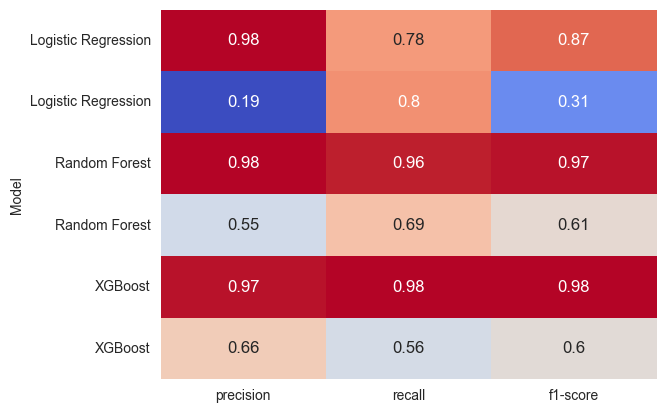

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.heatmap(
    new_comparison_df.set_index("Model").iloc[:, 1:4],
    annot=True,
    cmap="coolwarm",
    cbar=False,annot_kws={"size": 12}
)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

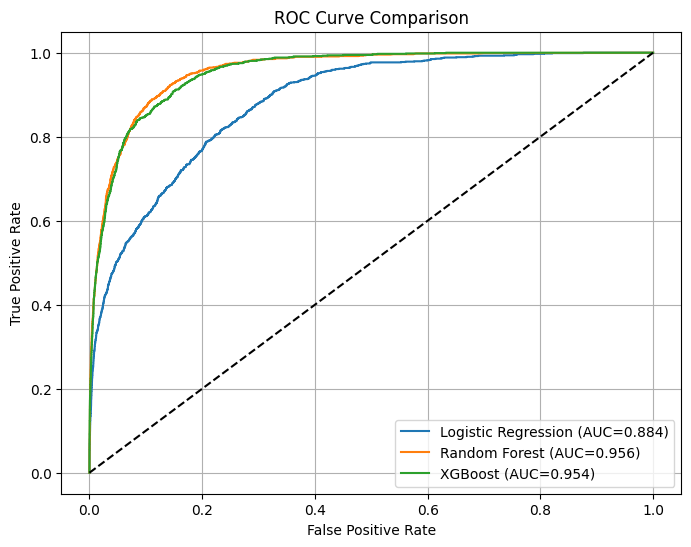

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC={auc_lr:.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC={auc_rf:.3f})')

plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC={auc_xgb:.3f})')

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig("roc_comparison.png", bbox_inches="tight")
plt.show()

In [ ]:
X_test

NameError: name 'X_test' is not defined